In [ ]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

from pre_processing import processed_img_preview, img_processing


In [ ]:
IMAGE_PATH = "./testing_data/sarala.png"
OUTPUT_DIR = "./segmentation_output"
NUMBER_OF_LETTERS = 2

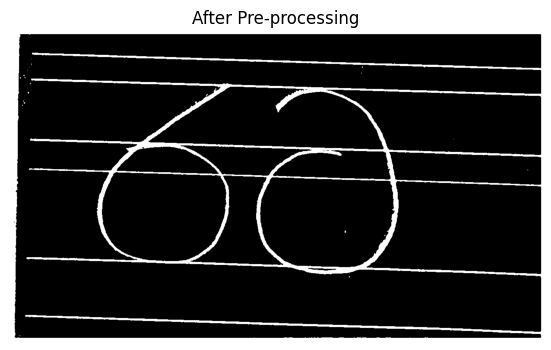

In [ ]:
img = cv2.imread(IMAGE_PATH)

if img is None:
    raise ValueError("Image not found")

clean = img_processing(img)

plt.figure(figsize=(8,4))
plt.imshow(clean, cmap="gray")
plt.title("After Pre-processing")
plt.axis("off")
plt.show()


In [ ]:
def vertical_projection(binary_img):
    # sum white pixels column-wise
    return np.sum(binary_img > 0, axis=0)


In [ ]:
def smooth_projection(proj):
    # Savitzky–Golay smoothing
    return savgol_filter(proj, 21, 3)


In [ ]:
def find_split_points(proj, num_letters, margin_ratio=0.06):
    w = len(proj)
    margin = int(w * margin_ratio)
    valid_proj = proj[margin : w - margin]

    if num_letters <= 1 or len(valid_proj) == 0:
        return []

    # --- low-density threshold ---
    min_val = np.min(valid_proj)
    max_val = np.max(valid_proj)
    threshold = min_val + 0.08 * (max_val - min_val)
    low_mask = valid_proj <= threshold

    # --- extract valley segments ---
    valleys = []
    start = None
    for i, v in enumerate(low_mask):
        if v and start is None:
            start = i
        elif not v and start is not None:
            valleys.append((start, i - 1))
            start = None
    if start is not None:
        valleys.append((start, len(low_mask) - 1))

    if not valleys:
        return []

    # --- divide word into logical regions ---
    region_width = len(valid_proj) / num_letters
    region_centers = [(i + 1) * region_width for i in range(num_letters - 1)]

    splits = []

    for rc in region_centers:
        # pick valley whose CENTER is closest to this region center
        best = None
        best_dist = float("inf")

        for s, e in valleys:
            c = (s + e) / 2
            dist = abs(c - rc)
            if dist < best_dist:
                best = (s, e)
                best_dist = dist

        if best is not None:
            s, e = best
            splits.append(int((s + e) / 2) + margin)

    return sorted(splits)


In [ ]:
def split_by_vertical_projection(binary_img, num_letters):
    proj = vertical_projection(binary_img)
    proj_smooth = smooth_projection(proj)

    splits = find_split_points(proj_smooth, num_letters)

    h, w = binary_img.shape
    xs = [0] + splits + [w]

    letters = []
    for i in range(len(xs) - 1):
        part = binary_img[:, xs[i]:xs[i+1]]
        letters.append(part)

    return letters, proj_smooth, splits


In [ ]:
def preview_projection(binary_img, proj, splits):
    plt.figure(figsize=(10,3))
    plt.plot(proj)
    for s in splits:
        plt.axvline(s, color="red")
    plt.title("Vertical Projection + Split Points")
    plt.show()


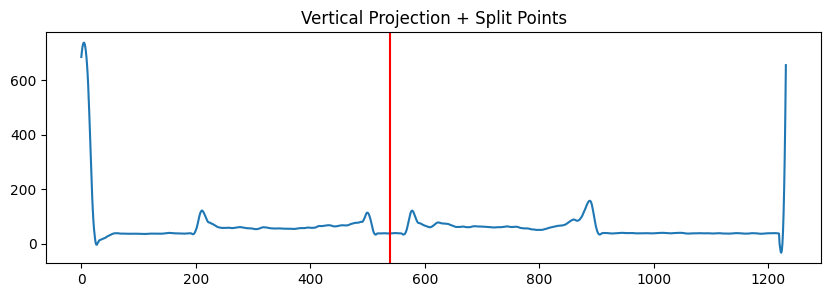

In [ ]:
num_letters = NUMBER_OF_LETTERS 

letters, proj, splits = split_by_vertical_projection(clean, num_letters)

preview_projection(clean, proj, splits)


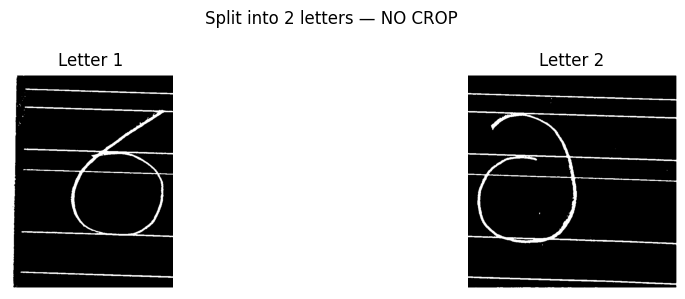

In [ ]:
plt.figure(figsize=(12,3))

for i, l in enumerate(letters):
    plt.subplot(1, len(letters), i+1)
    plt.imshow(l, cmap="gray")
    plt.title(f"Letter {i+1}")
    plt.axis("off")

plt.suptitle(f"Split into {len(letters)} letters — NO CROP")
plt.tight_layout()
plt.show()


In [ ]:
def tight_crop(img):
    ys, xs = np.where(img > 0)
    if len(xs) == 0:
        return img
    return img[ys.min():ys.max()+1, xs.min():xs.max()+1]


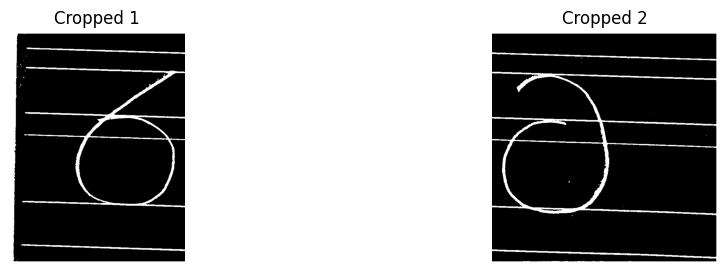

In [ ]:
cropped_letters = [tight_crop(l) for l in letters]

plt.figure(figsize=(12,3))
for i, l in enumerate(cropped_letters):
    plt.subplot(1, len(cropped_letters), i+1)
    plt.imshow(l, cmap="gray")
    plt.title(f"Cropped {i+1}")
    plt.axis("off")
plt.show()


In [ ]:
out_dir = OUTPUT_DIR
os.makedirs(out_dir, exist_ok=True)

for i, l in enumerate(cropped_letters):
    cv2.imwrite(f"{out_dir}/char_{i+1}.png", l)

print("Saved segmented letters to:", out_dir)


Saved segmented letters to: ./segmentation_output
